# Project Python Foundations: FoodHub Data Analysis

## Background

### Context

New York has more restaurants each day, serving busy people who rely on food delivery. FoodHub connects users to many restaurants through one app. Customers order, restaurants confirm, and a delivery person picks up and drops off the food. FoodHub earns a fixed margin from each order.


### Objective

FoodHub stores customer order data and wants to analyze it to understand restaurant demand. As a Data Scientist, the goal is to uncover patterns—like top-performing restaurants, peak order times, and repeat customer behavior—to help improve service and boost business strategy.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

| Column Name             | Description                                                                                                                                                      |
|------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `order_id`             | Unique ID of the order                                                                                                                                            |
| `customer_id`          | ID of the customer who ordered the food                                                                                                                           |
| `restaurant_name`      | Name of the restaurant                                                                                                                                            |
| `cuisine_type`         | Cuisine ordered by the customer                                                                                                                                   |
| `cost_of_the_order`    | Cost of the order                                                                                                                                                 |
| `day_of_the_week`      | Indicates whether the order is placed on a weekday or weekend (Weekday: Monday to Friday, Weekend: Saturday and Sunday)                                          |
| `rating`               | Rating given by the customer out of 5                                                                                                                             |
| `food_preparation_time`| Time (in minutes) taken by the restaurant to prepare the food. Calculated as the difference between restaurant's order confirmation and delivery pick-up time.    |
| `delivery_time`        | Time (in minutes) taken by the delivery person to deliver the food. Calculated as the difference between pick-up confirmation and drop-off timestamp.            |

## Importing the required libraries

In [1]:
# Installing the libraries with the specified version.
# !pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Data Structure

In [2]:
# Read the data
dataset = pd.read_csv('foodhub_order.csv')
dataset.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data?

In [3]:
print(f"Number of rows: {dataset.shape[0]}, Number of columns: {dataset.shape[1]}")

Number of rows: 1898, Number of columns: 9


#### Observations:
A quick summary of the dataset's structure, reveals 1898 records and 11 features.

### **Question 2:** What are the datatypes of the different columns in the dataset? 

In [4]:
print("Data types of each column:")
print(dataset.dtypes)

Data types of each column:
order_id                   int64
customer_id                int64
restaurant_name              str
cuisine_type                 str
cost_of_the_order        float64
day_of_the_week              str
rating                       str
food_preparation_time      int64
delivery_time              int64
dtype: object


#### Observations:


The dataset comprises a mix of numerical and categorical variables. Identifiers such as `order_id` and `customer_id` are stored as integers (`int64`), while `cost_of_the_order` is a continuous variable represented as `float64`. Categorical attributes like `restaurant_name`, `cuisine_type`, `day_of_the_week`, and `rating` are stored as `object` types, indicating string-based or mixed-type entries. Operational metrics such as `food_preparation_time` and `delivery_time` are also captured as integers, suggesting they represent durations in consistent units (e.g., minutes). 

This schema supports both descriptive analysis and predictive modeling, with clear separation between identifiers, categories, and measurable quantities.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.

In [5]:
# Check for missing values
print("Missing values per column:")
print(dataset.isnull().sum())


# Check for missing values and fill them based on column type if any
missing = dataset.isnull().sum()

if missing.sum() > 0:
    print("Missing values detected:")

    # Fill missing values by column type
    for col in dataset.columns:
        if dataset[col].dtype == 'object':
            dataset[col].fillna("Unknown", inplace=True)
        elif pd.api.types.is_integer_dtype(dataset[col]):
            dataset[col].fillna(0, inplace=True)
        elif pd.api.types.is_datetime64_any_dtype(dataset[col]):
            dataset[col].fillna(pd.Timestamp("1900-01-01"), inplace=True)

    print("Missing values have been filled based on column type.")
    
elif missing.sum() == 0:
    print("No missing values detected.")    

Missing values per column:
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64
No missing values detected.


#### Observations:


The absence of nulls across all fields indicates a high-integrity dataset that requires no missing value handling, enabling smooth preprocessing, reliable feature engineering, and confident deployment in automated analytics or machine learning workflows

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? 

In [6]:
# Statistical summary of the dataset
print("Summary statistics:")
print(dataset.describe())


# Preparation time stats
min_time = dataset['food_preparation_time'].min()
avg_time = round(dataset['food_preparation_time'].mean(), 1)
max_time = dataset['food_preparation_time'].max()


Summary statistics:
           order_id    customer_id  cost_of_the_order  food_preparation_time  \
count  1.898000e+03    1898.000000        1898.000000            1898.000000   
mean   1.477496e+06  171168.478398          16.498851              27.371970   
std    5.480497e+02  113698.139743           7.483812               4.632481   
min    1.476547e+06    1311.000000           4.470000              20.000000   
25%    1.477021e+06   77787.750000          12.080000              23.000000   
50%    1.477496e+06  128600.000000          14.140000              27.000000   
75%    1.477970e+06  270525.000000          22.297500              31.000000   
max    1.478444e+06  405334.000000          35.410000              35.000000   

       delivery_time  
count    1898.000000  
mean       24.161749  
std         4.972637  
min        15.000000  
25%        20.000000  
50%        25.000000  
75%        28.000000  
max        33.000000  


#### Observations:

>- The dataset contains 1,898 orders with complete records. On average, orders cost $16.50, takes approximately 27 minutes to prepare, and are delivered in approximately 24 minutes.
>- **Order costs** range from **$4.47** to **$35.41**,  while **delivery times** span **15** to **33 minutes** showing **moderate variability** across orders.

In [7]:
print(
    f"It takes a minimum preparation time of {min_time} minutes,"
    f"with an average preparation time of {avg_time} minutes,\n"
    f"and a maximum preparation time of {max_time} minutes once an order is placed."
)

It takes a minimum preparation time of 20 minutes,with an average preparation time of 27.4 minutes,
and a maximum preparation time of 35 minutes once an order is placed.


### **Question 5:** How many orders are not rated?

In [8]:
print("Number of unrated orders:", dataset['rating'].isnull().sum())

Number of unrated orders: 0


#### Observations:


All orders in the dataset have a valid rating — there are no missing values in the rating column. This means the data is complete and ready for analysis without needing imputation or filtering for that field

## Exploratory Data Analysis (EDA)

### Univariate Analysis

#### **Question 6:** Explore all the variables and provide observations on their distributions.

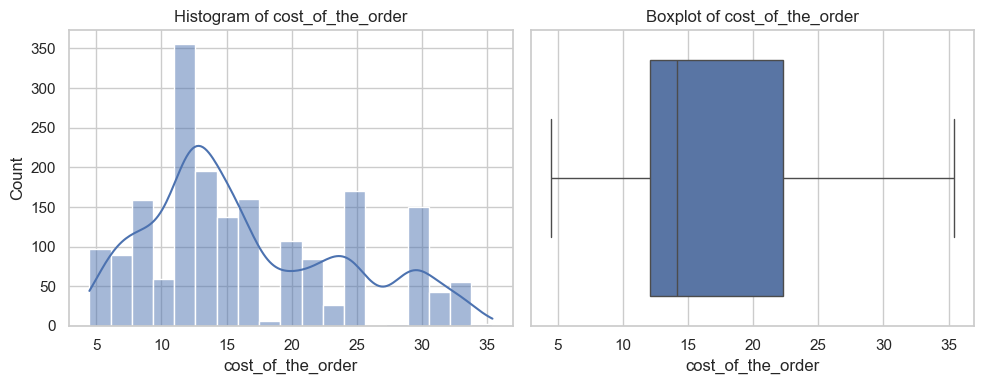

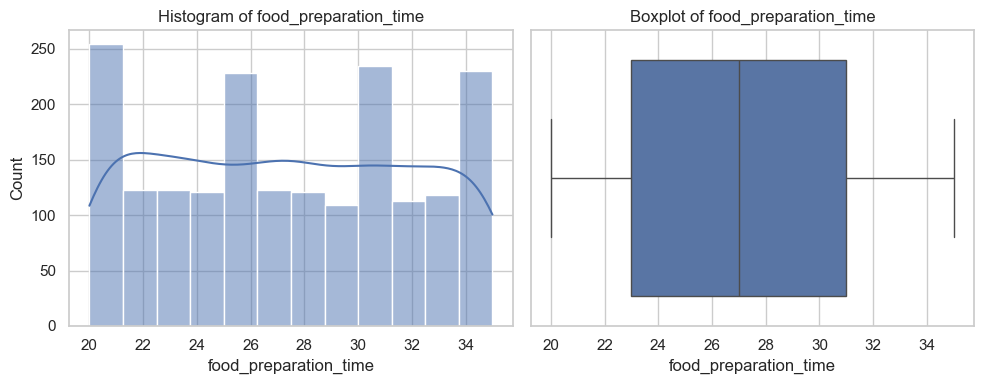

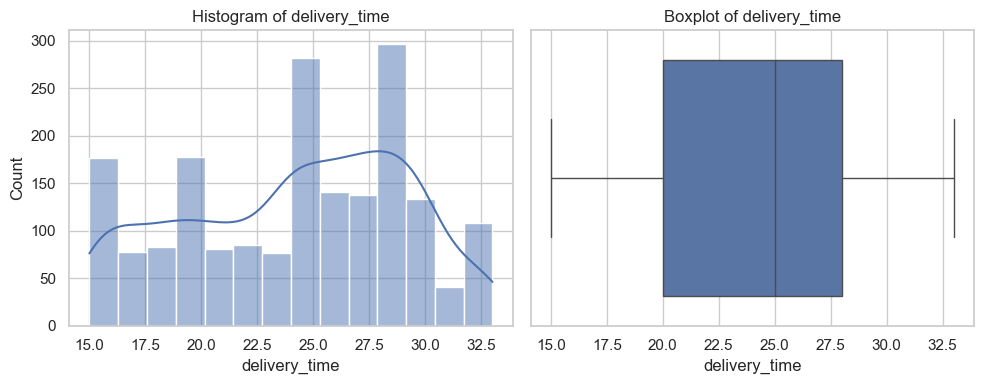

In [9]:
# Set style for plots
sns.set(style="whitegrid")

# Numeric columns excluding 'order_id'
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.drop(['order_id', 'customer_id'])

# Plot histograms and boxplots for numeric columns
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()




**1. `cost_of_the_order`**
>- The histogram is **slightly right-skewed**, showing more lower-cost orders.
>- Most order costs fall between **10–20 units**, with few above 30.
>- Boxplot indicates moderate dispersion, **no significant outliers**.
>- Suggests that most orders are of modest value — a few higher-cost ones exist but aren’t extreme.

**2. `food_preparation_time`**
>- Distribution is **fairly uniform** between 20 and 35 minutes — no visible skew.
>- Boxplot shows an **even spread**, with the median around **27 minutes**.
>- No outliers, suggesting **consistent kitchen operations** or well-controlled prep times.
>- Low variability implies predictable preparation process.

**3. `delivery_time`**
>- Delivery times are **fairly evenly distributed** between 15 and 33 minutes, slightly concentrated near 25–28 minutes.
>- Boxplot shows median delivery time ≈ **25 minutes**, again with **no outliers**.
>- Indicates **stable and reliable delivery durations** with minimal extreme delays.

**Overall summary:**
* All numerical variables show **no significant outliers** — data is clean and well-behaved.
* Operational times (`food_preparation_time`, `delivery_time`) are **consistent**, while `cost_of_the_order` shows typical customer spending patterns.
* `customer_id` variability is expected and likely not analytically relevant for modeling.

/var/folders/s6/7k4fm17x4tddpyq7pqjhgp6h0000gn/T/ipykernel_97135/1514743479.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include='object').columns.drop('restaurant_name')


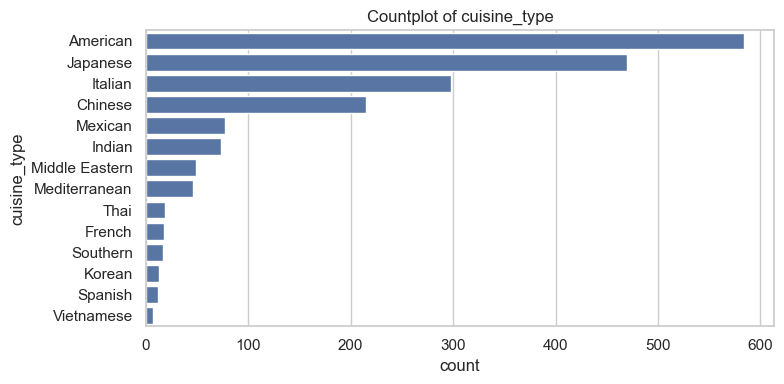

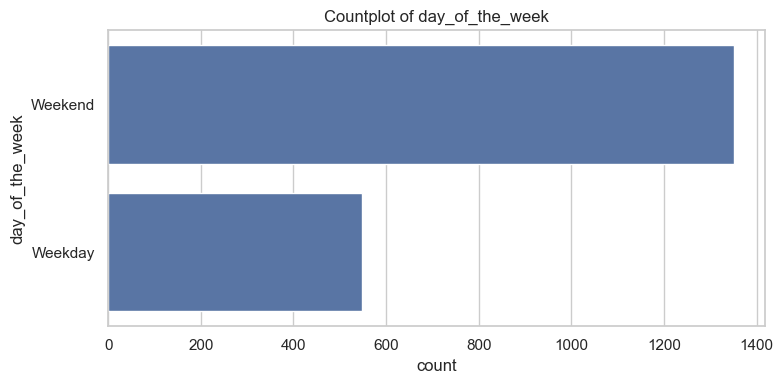

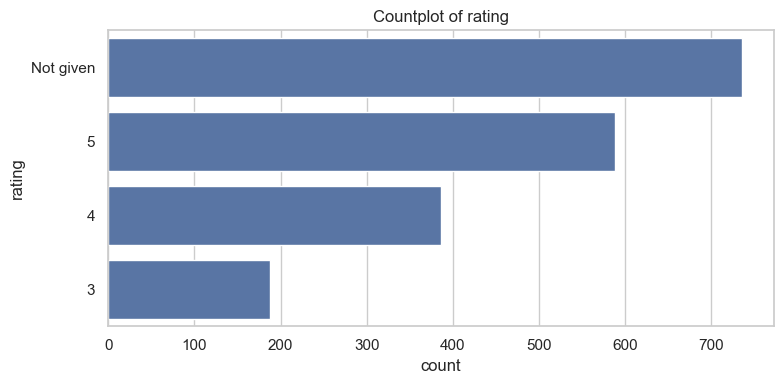

In [10]:
# Categorical columns
sns.set(style="whitegrid")

# Numeric columns excluding 'order_id'
categorical_cols = dataset.select_dtypes(include='object').columns.drop('restaurant_name')

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=dataset[col], order=dataset[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.tight_layout()
    plt.show()

**1. `cuisine_type`**
>- Most orders are for **American, Japanese, and Italian** cuisines, showing clear customer preference.
>- **Chinese, Mexican, and Indian** cuisines have moderate demand, while others are far less popular.
>- Suggests focusing marketing and menu optimization on **top cuisines** while exploring strategies to boost underrepresented ones.

 **2. `day_of_the_week`**
>- **Weekend orders** are nearly twice as frequent as weekday orders.
>- Indicates **peak demand during weekends**, likely for leisure or family dining.
>- Operations and staffing should be **scaled up on weekends** and promotions targeted to **boost weekday sales**.

 **3. `rating`**
>- A large share of customers **did not provide ratings**, indicating **low feedback engagement**.
>- Among available ratings, **5-star reviews dominate**, followed by 4-star — reflecting **high satisfaction**.
>- Suggests encouraging more feedback to **capture a fuller picture of customer experience**.


#### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received?

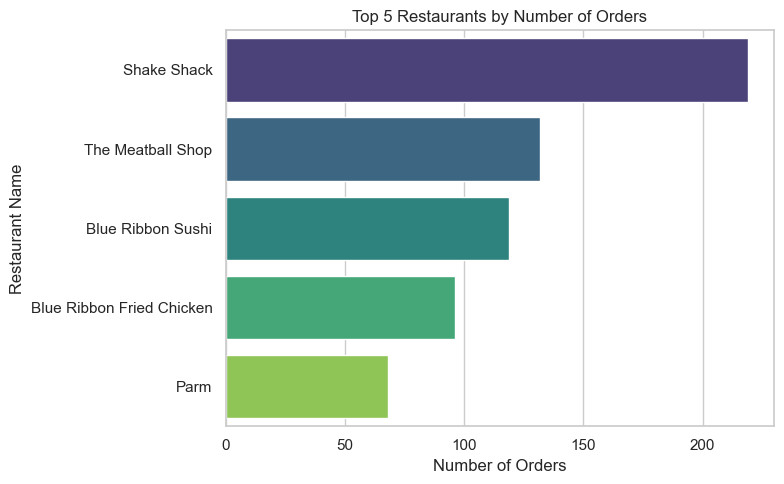

Top 5 restaurants by number of orders:
Shake Shack: 219 orders
The Meatball Shop: 132 orders
Blue Ribbon Sushi: 119 orders
Blue Ribbon Fried Chicken: 96 orders
Parm: 68 orders


In [11]:
# Count top 5 restaurants
top_restaurants = dataset['restaurant_name'].value_counts().head(5)

# Bar plot for top 5 restaurants
plt.figure(figsize=(8, 5))
sns.barplot(x=top_restaurants.values, 
            y=top_restaurants.index, 
            hue=top_restaurants.index, 
            palette="viridis", legend=False)
plt.title("Top 5 Restaurants by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.tight_layout()
plt.show()


# Print statement
print("Top 5 restaurants by number of orders:")
for name, count in top_restaurants.items():
    print(f"{name}: {count} orders")

##### Observations:

* **Shake Shack** leads significantly, receiving the **highest number of orders**, indicating strong brand popularity and customer loyalty.
* **The Meatball Shop** and **Blue Ribbon Sushi** follow closely, showing consistent customer demand and likely strong menu appeal.
* **Blue Ribbon Fried Chicken** and **Parm** round out the top five, with moderate but steady order volumes, suggesting **room for growth** through targeted marketing or promotions.

#### **Question 8**: Which is the most popular cuisine on weekends?

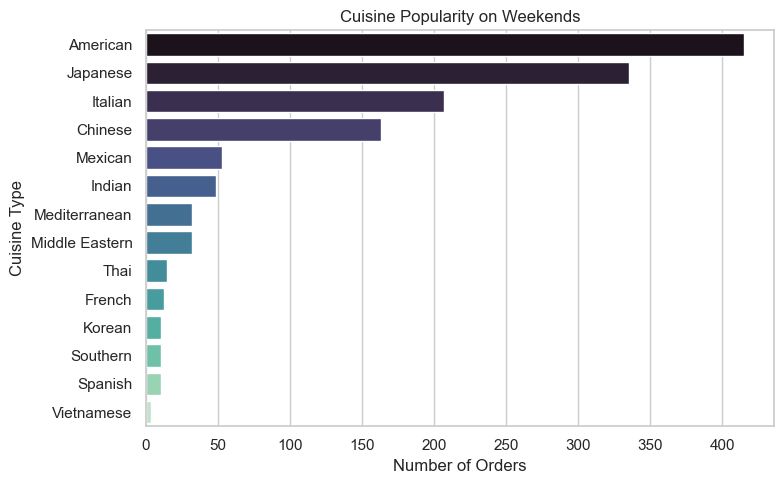

The most popular cuisine on weekends is American with 415 orders.


In [12]:
# Filter for weekend orders
weekend_orders = dataset[dataset['day_of_the_week'].isin(['Weekend'])]

# Count cuisine types
top_cuisine = weekend_orders['cuisine_type'].value_counts()
most_popular_name = top_cuisine.index[0]
most_popular_count = top_cuisine.iloc[0]

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=top_cuisine.values, 
            y=top_cuisine.index, 
            hue=top_cuisine.index, 
            palette="mako", legend=False)


plt.title("Cuisine Popularity on Weekends")
plt.xlabel("Number of Orders")
plt.ylabel("Cuisine Type")
plt.tight_layout()
plt.show()


# Print statement
print(f"The most popular cuisine on weekends is {most_popular_name} with {most_popular_count} orders.")


##### Observations:

**Cuisine Popularity on Weekends**
>* **American** and **Japanese** cuisines dominate weekend orders, highlighting their strong appeal for leisure or group dining.
>* **Italian** and **Chinese** cuisines follow as preferred secondary options, maintaining steady demand.
>* Other cuisines like **Mexican**, **Indian**, and **Mediterranean** show limited but consistent interest, indicating **niche customer segments** that could be expanded with targeted promotions.


#### **Question 9**: What percentage of the orders cost more than 20 dollars?

In [13]:
# Calculate percentage
total_orders = dataset.shape[0]
high_cost_orders = dataset[dataset['cost_of_the_order'] > 20].shape[0]
percentage = round((high_cost_orders / total_orders) * 100, 2)

# Print statement
print(f"{percentage}% of the orders cost more than $20.")

29.24% of the orders cost more than $20.


##### Observations:

* About **29.24%** of the orders cost **more than $20**, meaning **roughly one in three customers** places a higher-value order.
* The majority (around **70%**) of orders fall below $20, showing a **price-sensitive customer base** with a focus on affordability.
* This insight suggests an opportunity to **increase average order value** through targeted promotions such as **combo offers, add-ons, or loyalty rewards** for premium orders.


#### **Question 10**: What is the mean order delivery time?

In [14]:
avg_delivery = round(dataset['delivery_time'].mean(), 2)
min_delivery = dataset['delivery_time'].min()
max_delivery = dataset['delivery_time'].max()

print(f"The average order delivery time is {avg_delivery} minutes.")

The average order delivery time is 24.16 minutes.


##### Observations:

* The **average delivery time of 24.16 minutes** indicates a **reasonably efficient delivery process**, falling within an acceptable range for food services.
* This suggests that the **logistics and delivery operations are performing well**, ensuring timely customer satisfaction.
* However, continuous monitoring is recommended to **maintain consistency** and identify potential delays during **peak hours or weekends**.

#### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed.

In [15]:
# Count orders per customer
top_customers = dataset['customer_id'].value_counts().head(3)

# Print results
print("Top 3 most frequent customers eligible for 20% discount vouchers:")
for customer_id, order_count in top_customers.items():
    print(f"Customer ID: {customer_id} — Orders placed: {order_count}")

Top 3 most frequent customers eligible for 20% discount vouchers:
Customer ID: 52832 — Orders placed: 13
Customer ID: 47440 — Orders placed: 10
Customer ID: 83287 — Orders placed: 9


##### Observations:

* The top three customers account for a **notable concentration of repeat orders**, suggesting a **small but highly engaged segment** driving recurring revenue.
* Offering them a **20% discount voucher** is both a reward and a **strategic retention move** — it reinforces loyalty while potentially prompting even higher spending or order frequency.
* This pattern highlights the value of **focusing on high-frequency customers** through personalized offers or exclusive perks to **maximize lifetime value** and stabilize revenue.

### Multivariate Analysis

#### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) 


##### Numerical vs Numerical

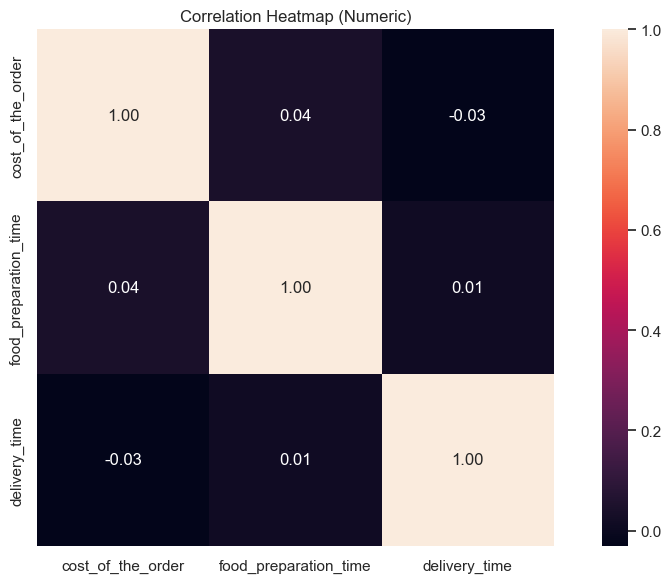

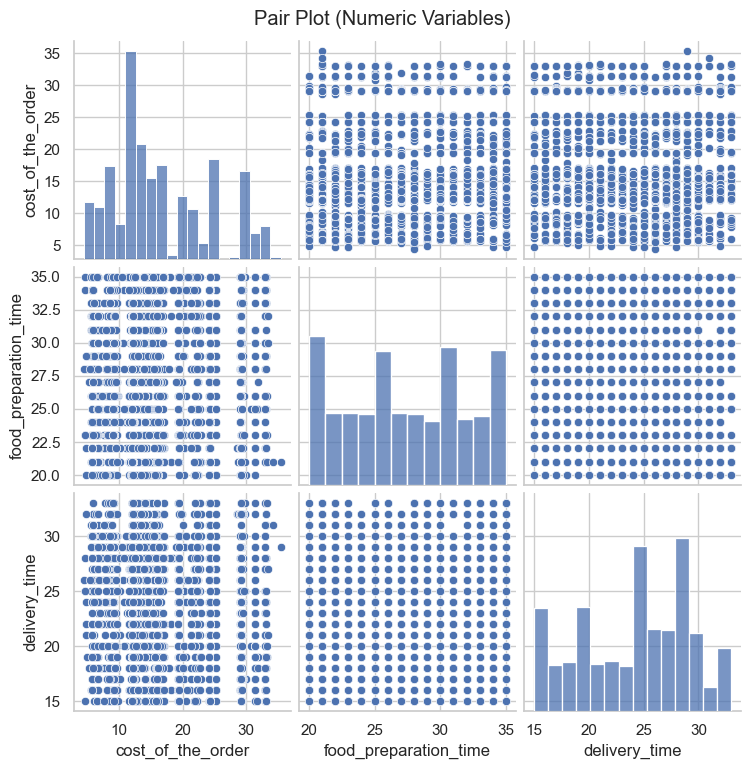

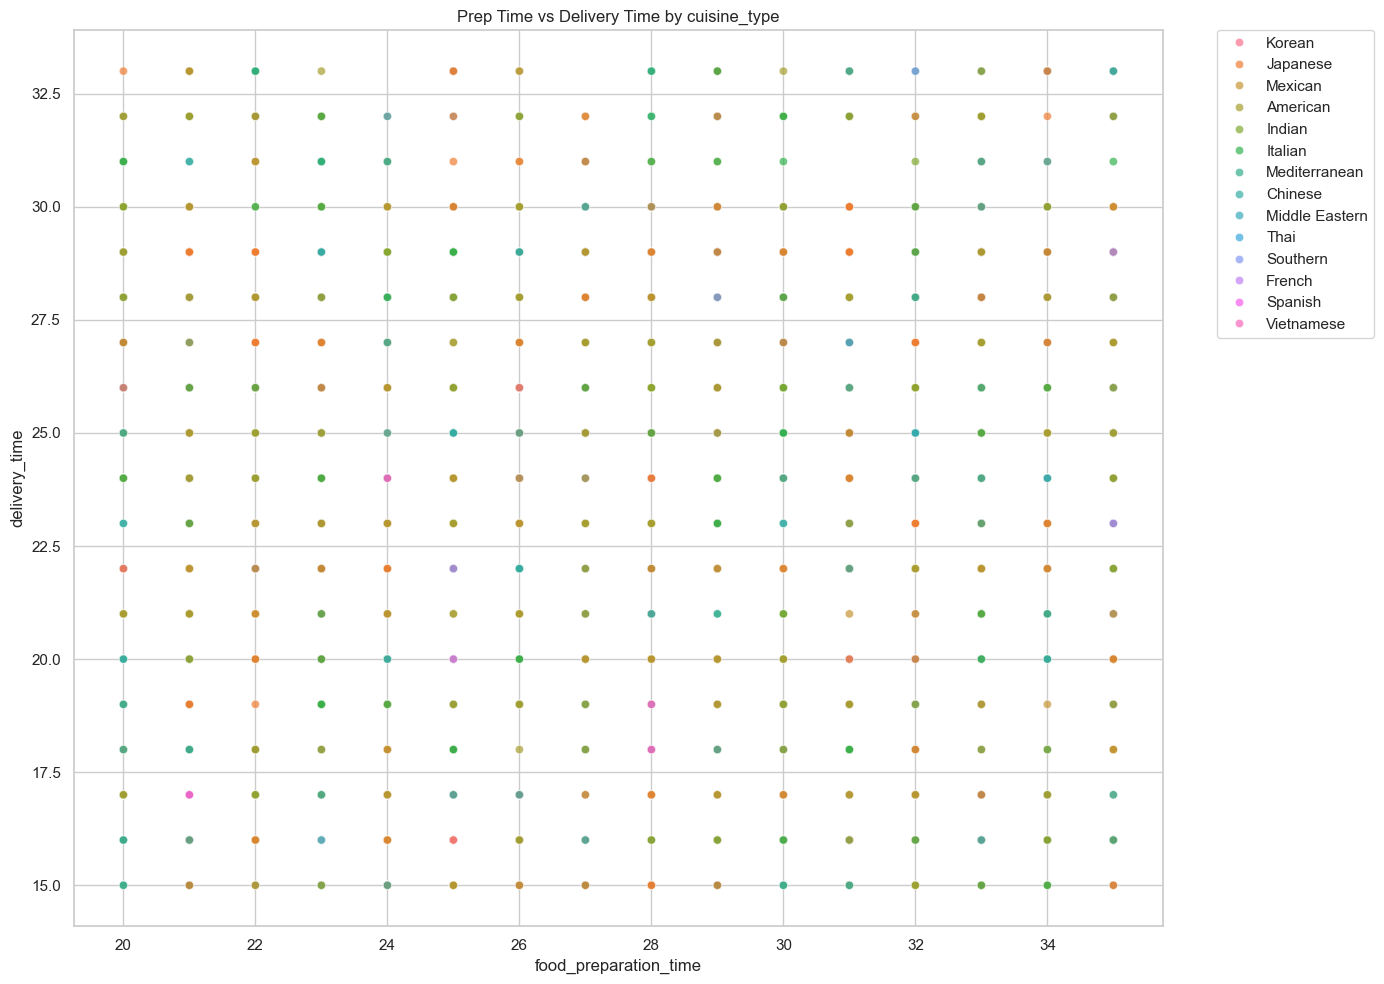

In [16]:
sns.set(style="whitegrid")

num_cols = [c for c in numeric_cols if c in dataset.columns]
cat_cols = [c for c in categorical_cols if c in dataset.columns]


# 1a) Correlation heatmap
if len(num_cols) >= 2:
    plt.figure(figsize=(10,6))
    corr = dataset[num_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, fmt=".2f", square=True)
    plt.title("Correlation Heatmap (Numeric)")
    plt.tight_layout()
    plt.show()

# 1b) Pair plot
if len(num_cols) >= 2:
    sns.pairplot(dataset[num_cols], diag_kind="hist")
    plt.suptitle("Pair Plot (Numeric Variables)", y=1.02)
    plt.show()

# 1c) Scatter with hue by a categorical (if available)
hue_col = next((c for c in ["cuisine_type", "day_of_the_week", "rating"] if c in dataset.columns), None)
if set(["food_preparation_time", "delivery_time"]).issubset(dataset.columns):
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=dataset,
        x="food_preparation_time",
        y="delivery_time",
        hue=hue_col if hue_col else None,
        alpha=0.7
    )
    plt.title("Prep Time vs Delivery Time" + (f" by {hue_col}" if hue_col else ""))
    
    # Move legend to the side (outside the plot)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    
    plt.tight_layout()
    plt.show()



**1. Correlation Heatmap (Numeric)**
* The correlations between `cost_of_the_order`, `food_preparation_time`, and `delivery_time` are **very weak (close to 0)**.
* This implies that **order cost, preparation time, and delivery time are largely independent** of one another.
* In practice, this means that **high-cost orders don’t necessarily take longer to prepare or deliver**, suggesting consistent operational performance across all order types.

 **2. Pair Plot (Numeric Variables)**
* Scatter distributions confirm the **lack of linear relationships** between numeric variables.
* `cost_of_the_order` and `food_preparation_time` show **no visible upward or downward trend**, reinforcing the weak correlation seen earlier.
* The uniform spread of points indicates **stable and well-managed processes**, with no strong dependency between preparation or delivery times and cost.

 **3. Prep Time vs Delivery Time by Cuisine Type**
* The scatterplot shows **no major separation by cuisine**, meaning **all cuisine types have similar prep and delivery time ranges**.
* Data points are **evenly distributed**, reflecting **consistent kitchen and delivery efficiency** regardless of cuisine type.
* This suggests operational standardization — **no cuisine is significantly slower or faster** to prepare and deliver.


##### Numerical vs Categorical (groups)

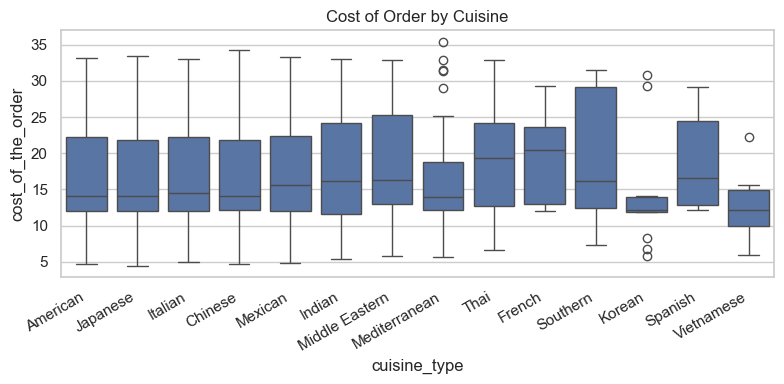

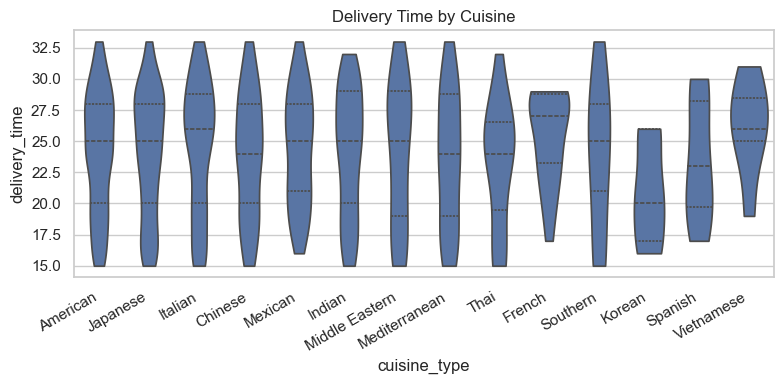

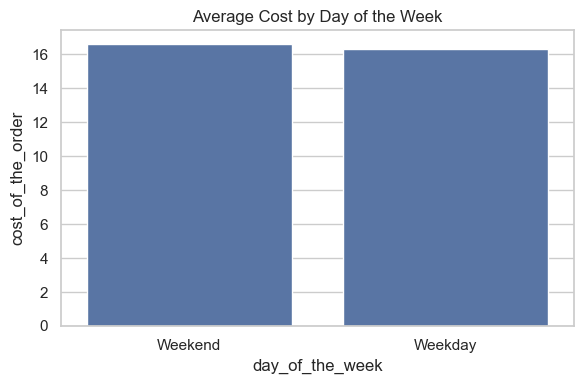

In [17]:
# 2a) Boxplots (cost by cuisine)
if {"cost_of_the_order","cuisine_type"}.issubset(dataset.columns):
    plt.figure(figsize=(8,4))
    order = dataset["cuisine_type"].value_counts().index
    sns.boxplot(data=dataset, x="cuisine_type", y="cost_of_the_order", order=order)
    plt.xticks(rotation=30, ha="right")
    plt.title("Cost of Order by Cuisine")
    plt.tight_layout()
    plt.show()


# 2b) Violin (delivery time by cuisine)
if {"delivery_time","cuisine_type"}.issubset(dataset.columns):
    plt.figure(figsize=(8,4))
    order = dataset["cuisine_type"].value_counts().index
    sns.violinplot(data=dataset, x="cuisine_type", y="delivery_time", order=order, inner="quartile", cut=0)
    plt.xticks(rotation=30, ha="right")
    plt.title("Delivery Time by Cuisine")
    plt.tight_layout()
    plt.show()

# 2c) Bar of means (avg cost by day)
if {"cost_of_the_order","day_of_the_week"}.issubset(dataset.columns):
    plt.figure(figsize=(6,4))
    sns.barplot(data=dataset, x="day_of_the_week", y="cost_of_the_order", estimator=np.mean, errorbar=None)
    plt.title("Average Cost by Day of the Week")
    plt.tight_layout()
    plt.show()
    

**1. Cost of Order by Cuisine**
* The **median cost** of orders is fairly consistent across cuisines, generally between **$15–$20**.
* **Southern**, **French**, and **Mediterranean** cuisines show slightly **higher average costs** and **greater variability**, implying they include more premium-priced dishes.
* **Korean** and **Vietnamese** cuisines have **lower and more compact cost ranges**, suggesting **simpler or budget-friendly menus**.

 **2. Delivery Time by Cuisine**
* Delivery times are **remarkably uniform across cuisines**, mostly centered between **20–30 minutes**.
* Slightly longer delivery times for **French**, **Southern**, and **Vietnamese** cuisines could be due to **higher preparation complexity or fewer outlets**.
* Overall, the consistent shape across cuisines indicates **efficient logistics and balanced delivery management** regardless of meal type.

**3. Average Cost by Day of the Week**
* The **average cost of orders is almost identical** on **weekdays and weekends** (around **$16**).
* This shows that **spending behavior remains stable** across the week, even though **order volume is higher on weekends**.
* Indicates that while **weekends drive more orders**, customers maintain **similar spending patterns per order**.


##### Categorical vs Categorical

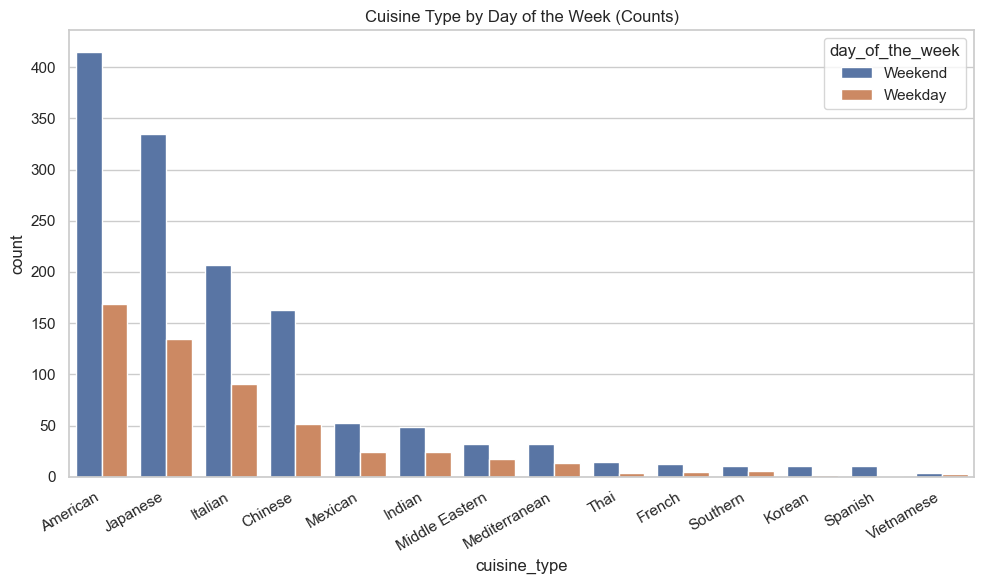

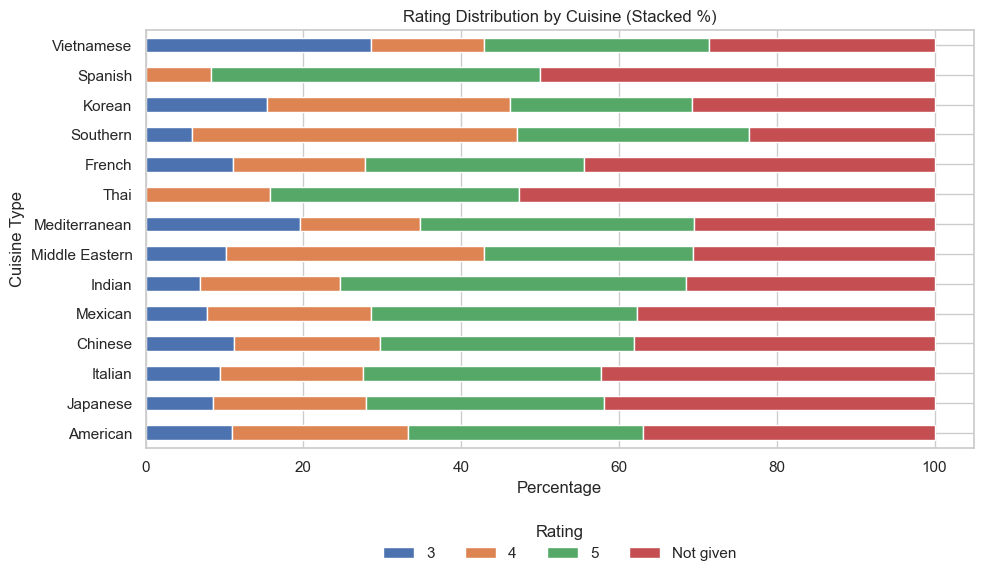

In [18]:
# 3a) Clustered countplot (cuisine by day)
if {"cuisine_type","day_of_the_week"}.issubset(dataset.columns):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=dataset, x="cuisine_type", hue="day_of_the_week",
                  order=dataset["cuisine_type"].value_counts().index)
    plt.xticks(rotation=30, ha="right")
    plt.title("Cuisine Type by Day of the Week (Counts)")
    plt.tight_layout()
    plt.show()

# 3b) Horizontal stacked bar (rating by cuisine)
if {"rating", "cuisine_type"}.issubset(dataset.columns):
    ct = pd.crosstab(dataset["cuisine_type"], dataset["rating"], normalize="index") * 100
    ct = ct.loc[dataset["cuisine_type"].value_counts().index]  # order by frequency

    ax = ct.plot(kind="barh", stacked=True, figsize=(10, 6))
    plt.title("Rating Distribution by Cuisine (Stacked %)")
    plt.xlabel("Percentage")
    plt.ylabel("Cuisine Type")

    # Move legend to the bottom, neat and space-efficient
    plt.legend(
        title="Rating",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=len(ct.columns),
        frameon=False
    )

    plt.tight_layout()
    plt.show()



**1. Cuisine Type by Day of the Week (Counts)**
* **American, Japanese, and Italian cuisines** dominate on both weekdays and weekends, but **weekend orders are significantly higher** across all cuisine types.
* The strong weekend preference indicates that **customers are more likely to dine or order out during leisure periods**, especially for popular cuisines.
* Less popular cuisines such as **Spanish, Korean, and Vietnamese** show minimal weekday variation, suggesting **niche or loyal customer segments**.

**2. Rating Distribution by Cuisine (Stacked %)**
* A large proportion of orders have **“Not given” ratings**, indicating **low feedback participation** across all cuisines.
* Among rated orders, **5-star ratings** are most frequent, showing **generally high customer satisfaction** regardless of cuisine type.
* Minor variation exists — cuisines like **Italian and Japanese** receive slightly more 5-star ratings, while others such as **Middle Eastern or Southern** show a more balanced mix, implying **consistent quality but room for improvement in engagement**.


##### Mixed / Multivariate

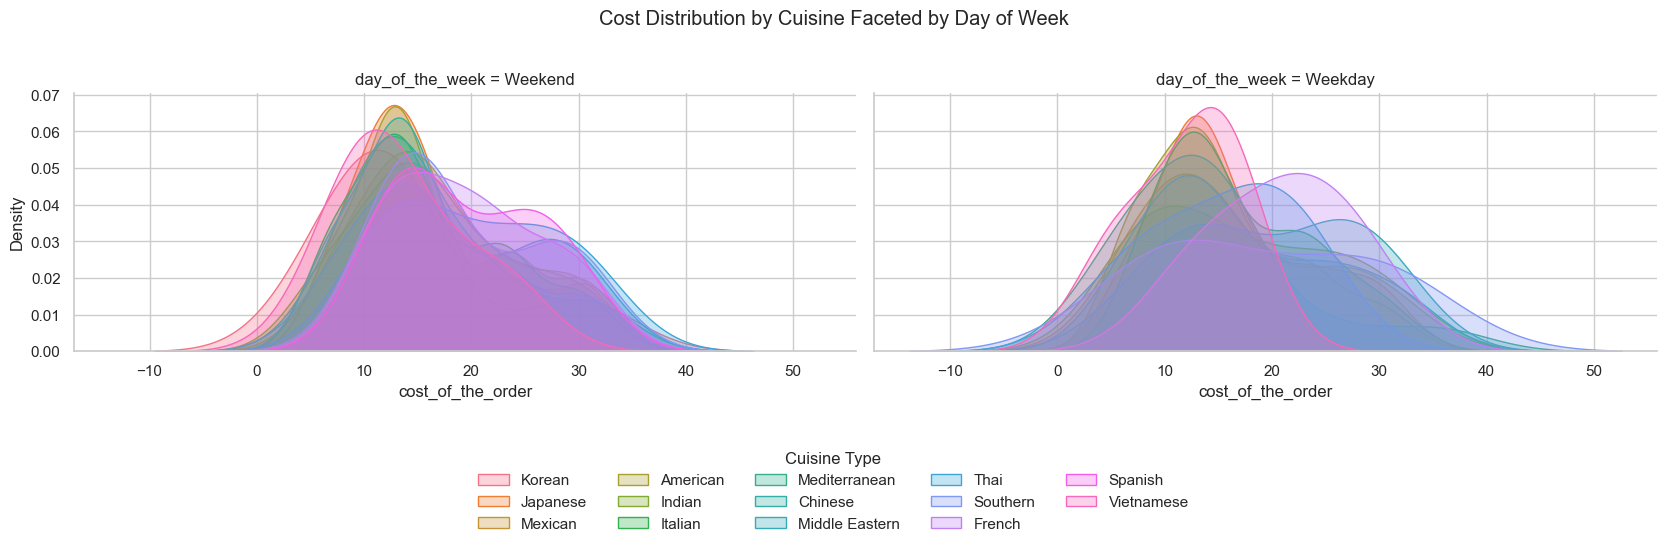

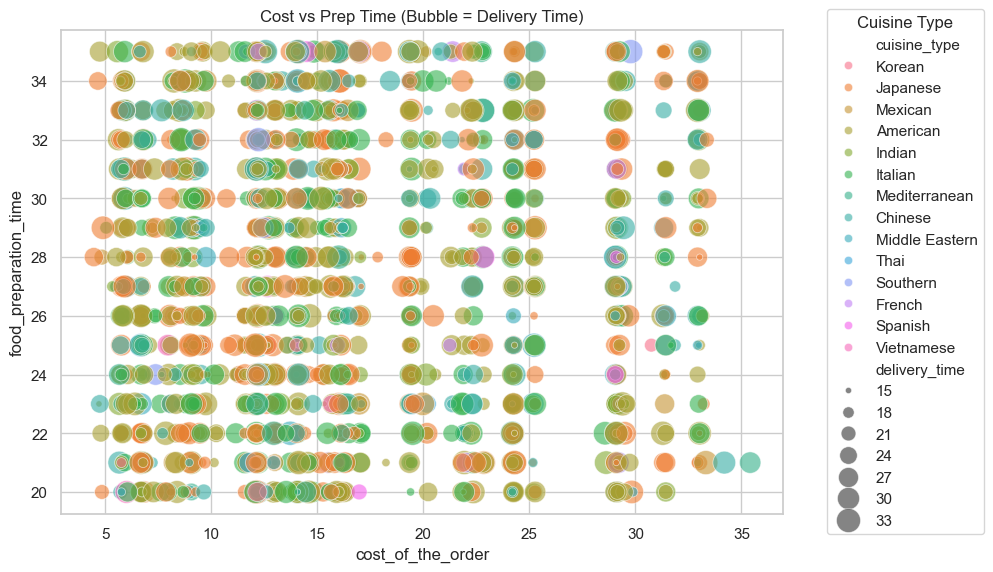

In [19]:
# 4a) FacetGrid: cost distribution by cuisine, faceted by day
if {"cost_of_the_order", "cuisine_type", "day_of_the_week"}.issubset(dataset.columns):
    g = sns.FacetGrid(dataset, col="day_of_the_week", hue="cuisine_type", height=4, aspect=1.2)
    g.map(sns.kdeplot, "cost_of_the_order", fill=True, alpha=0.3, warn_singular=False)
    g.add_legend(title="Cuisine Type", bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=5)
    g.fig.suptitle("Cost Distribution by Cuisine Faceted by Day of Week", y=1.02)
    plt.tight_layout()
    plt.show()
    

# 4b) Bubble chart: cost vs prep, bubble = delivery time, hue = cuisine
if {"cost_of_the_order", "food_preparation_time", "delivery_time"}.issubset(dataset.columns):
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=dataset,
        x="cost_of_the_order",
        y="food_preparation_time",
        size="delivery_time",
        hue=hue_col if hue_col else None,
        sizes=(20, 300),
        alpha=0.6
    )
    plt.title("Cost vs Prep Time (Bubble = Delivery Time)")
    plt.legend(title="Cuisine Type", bbox_to_anchor=(1.05, 0.5), loc="center left")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


 **1. Cost Distribution by Cuisine Faceted by Day of Week**
* Both **weekday and weekend distributions** follow a similar bell-shaped pattern, with most orders clustering around **$10–$25**.
* The curves overlap heavily, confirming that **customer spending patterns remain steady** between weekdays and weekends.
* Variations between cuisines are minor — a few, like **French and Mediterranean**, show a slightly wider cost range, possibly reflecting **premium menu options**.

 
 **2. Cost vs Prep Time (Bubble = Delivery Time)**
* The **bubbles are evenly distributed**, showing **no strong correlation** between `cost_of_the_order` and `food_preparation_time`.
* Bubble sizes (representing `delivery_time`) remain fairly consistent, indicating **stable delivery durations** regardless of order value or preparation effort.
* The diverse color spread across all cost and prep ranges suggests **uniform operational efficiency** across cuisines — no cuisine clearly takes longer or costs significantly more on average.




### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer.

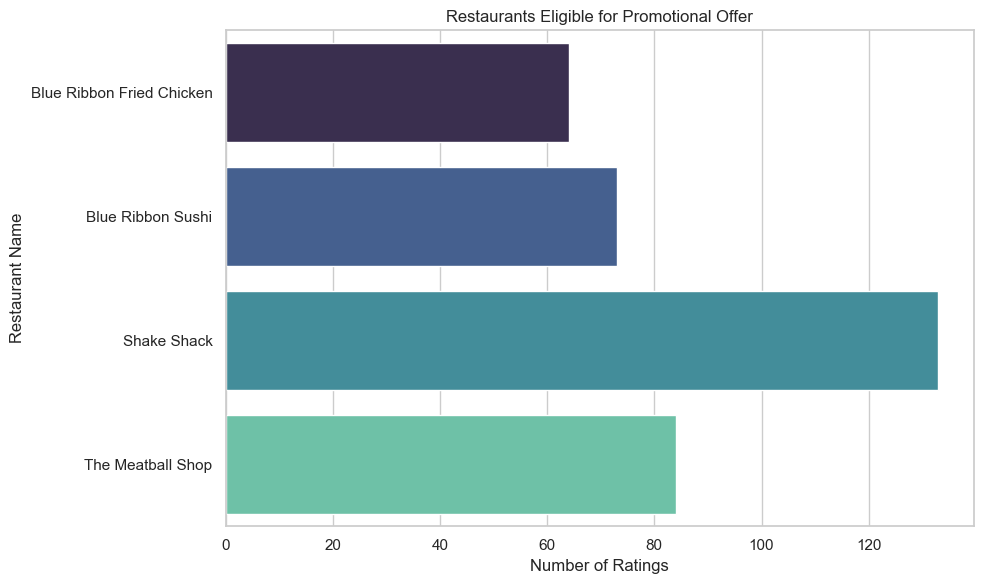

Restaurants eligible for the promotional offer:
Blue Ribbon Fried Chicken — Count: 64.0, Average Rating: 4.3
Blue Ribbon Sushi — Count: 73.0, Average Rating: 4.2
Shake Shack — Count: 133.0, Average Rating: 4.3
The Meatball Shop — Count: 84.0, Average Rating: 4.5


In [20]:
# Ensure 'rating' is numeric
dataset['rating'] = pd.to_numeric(dataset['rating'], errors='coerce')

# Group by restaurant and calculate rating count and average
rating_stats = dataset.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter based on conditions
eligible_restaurants = rating_stats[(rating_stats['count'] > 50) & (rating_stats['mean'] > 4)]
    
# Visualization: Number of Ratings for Eligible Restaurants
plt.figure(figsize=(10, 6))
sns.barplot(
    data=eligible_restaurants,
    x='count',
    y='restaurant_name',
    hue=eligible_restaurants.index,
    palette='mako'
)

plt.title("Restaurants Eligible for Promotional Offer")
plt.xlabel("Number of Ratings")
plt.ylabel("Restaurant Name")
plt.tight_layout()
plt.show()


print("Restaurants eligible for the promotional offer:")
for name, row in eligible_restaurants.iterrows():
    print(f"{name} — Count: {row['count']}, Average Rating: {round(row['mean'], 1)}")
   

#### Observations:

* Four restaurants meet the promotional criteria — **Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop** — each having **more than 50 orders** and an **average rating above 4.0**.
* Among them, **The Meatball Shop** stands out with the **highest average rating (4.5)**, indicating strong customer satisfaction and suitability for brand promotion.
* **Shake Shack**, with the **highest number of orders (133)**, offers the **widest customer reach**, making it an ideal candidate for high-visibility promotional campaigns.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. 

In [21]:
# Apply commission logic
def calculate_commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Calculate revenue per order
dataset['commission'] = dataset['cost_of_the_order'].apply(calculate_commission)

# Total revenue
net_revenue = round(dataset['commission'].sum(), 2)

# Print result
print(f"The net revenue generated by the company across all orders is ${net_revenue}.")

The net revenue generated by the company across all orders is $6166.3.


#### Observations:

* Based on the given commission structure, the **net revenue generated by the company is $6,166.30** across all orders.
* The majority of this revenue likely comes from **orders priced between $5 and $20**, as they represent the most common range and are charged a **15% commission**.
* High-value orders (above $20) contribute a smaller portion in count but a higher **per-order margin (25%)**, indicating a **balanced revenue mix** driven by both order volume and premium pricing.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) 

In [22]:
# Total time per order
dataset['total_delivery_time'] = dataset['food_preparation_time'] + dataset['delivery_time']

# Calculate percentage
total_orders = dataset.shape[0]
long_orders = dataset[dataset['total_delivery_time'] > 60].shape[0]
percentage = round((long_orders / total_orders) * 100, 2)

# Print result
print(f"{percentage}% of orders take more than 60 minutes from placement to delivery.")

10.54% of orders take more than 60 minutes from placement to delivery.


#### Observation

* Around **10.54% of all orders** exceed the **60-minute total delivery threshold**, indicating that the **vast majority (nearly 90%)** of deliveries are completed within an hour.
* This reflects **strong operational efficiency** overall, though the delayed 10% may highlight **peak-hour congestion, longer prep times for certain cuisines, or logistical bottlenecks**.
* Targeting this segment through **process optimization or route planning improvements** could further enhance on-time delivery performance and overall customer satisfaction.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends?

In [23]:
# Calculate mean delivery time by day type
mean_delivery_by_day = dataset.groupby('day_of_the_week')['delivery_time'].mean().round(2)

weekday_mean = mean_delivery_by_day.get('Weekday', None)
weekend_mean = mean_delivery_by_day.get('Weekend', None)

# Conditional output
if weekday_mean is not None and weekend_mean is not None:
    if weekend_mean > weekday_mean:
        print(f"Mean delivery time is higher on weekends ({weekend_mean} mins) than on weekdays ({weekday_mean} mins).")
    elif weekend_mean < weekday_mean:
        print(f"Mean delivery time is higher on weekdays ({weekday_mean} mins) than on weekends ({weekend_mean} mins).")
    else:
        print(f"Mean delivery time is the same on weekdays and weekends: {weekday_mean} mins.")
else:
    print("Could not determine delivery time comparison due to missing data.")

Mean delivery time is higher on weekdays (28.34 mins) than on weekends (22.47 mins).


#### Observation

* The **average delivery time is higher on weekdays (28.34 minutes)** compared to **weekends (22.47 minutes)**, indicating that **weekday operations face more delays**.
* This difference may stem from **heavier traffic, higher order density during lunch hours, or tighter courier availability** on weekdays.
* The shorter weekend delivery times suggest **smoother logistics and less congestion**, highlighting an opportunity to **optimize weekday scheduling and route efficiency**.



## Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) 

* The analysis shows that **American, Japanese, and Italian cuisines** dominate customer preferences, driving the majority of orders and revenue. These should remain the company’s **core promotional focus**.

* **Customer satisfaction is generally high**, with most restaurants maintaining **average ratings above 4.0**. However, **low participation in ratings** suggests that **feedback collection mechanisms** (e.g., in-app reminders or loyalty incentives) could be strengthened to capture more insights.

* **Weekend demand is significantly higher**, while **weekday deliveries are slower**, indicating an operational gap. Optimizing **weekday delivery routes and staffing levels** could balance performance across all days.
* Only **10.54% of total orders exceed 60 minutes**, showing strong overall efficiency, but continued monitoring of **outlier delays** can help maintain service reliability.

* **Mid-range orders ($5–$20)** form the bulk of revenue under the commission structure, making them crucial for profitability. Upselling within this band through **combo offers or limited-time deals** could further boost revenue.
* Promotional offers should target **high-performing restaurants** like **Shake Shack** and **The Meatball Shop**, which combine **strong ratings with high order volumes**, ensuring maximum marketing impact.

**In summary:**
Focus marketing on top cuisines and high-rated restaurants, streamline weekday delivery operations, and strengthen customer feedback collection to drive continuous improvement and sustainable growth.


#### **Final Recommendations**

To enhance business performance, the company should:

* Implement a **loyalty and referral program** to retain existing customers and attract new ones.
* Offer **personalized promotions** based on order history and cuisine preferences to boost engagement.
* Encourage **customer feedback through small incentives** and publish **“Top Rated Restaurants” highlights** to promote transparency.
* **Analyze delayed orders**, optimize **driver scheduling**, and apply **real-time route management** to enhance delivery efficiency.
* Provide **data-driven insights** to restaurant partners and introduce **performance-based incentives** for maintaining high ratings and service quality.
* Support partners in **menu optimization**, promoting popular cuisines and improving underperforming offerings.
* These actions will collectively **increase customer satisfaction**, **streamline operations**, and **drive sustainable business growth**.



---